# EGX360 — THE DEEP QUANT MODEL Accuracy 89
### Enhancing Down-Trend Detection & Bias Control in the Egyptian Stock Exchange

## 1. Environment Setup & Initialization

In [392]:
import tensorflow as tf
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Success! GPU found: {gpu_devices}")
else:
    print("Still not working. Check PATH or CUDA version.")

Still not working. Check PATH or CUDA version.


In [393]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')
import os

## 2. Data Loading & Raw Market Visualization
We begin by loading the preprocessed EGX30 daily data. Financial time series data is notoriously noisy. Visualizing the raw candlesticks demonstrates why predicting raw daily closing prices is ineffective; the high volatility creates market noise that confuses standard predictive models.

In [400]:
print("🚀 Loading Final Dataset (EGX + USD + Gold)...")
current_dir = os.getcwd()

# 1. قراءة الملف اللي فيه الذهب والدولار
file_path = os.path.join(current_dir, "data", "EGX30_Final_v9.csv")
df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None).dt.normalize()
df.set_index('timestamp', inplace=True)


🚀 Loading Final Dataset (EGX + USD + Gold)...


In [401]:
ir_path = os.path.join(current_dir, "data", "cbe_interest_rate.csv")
if os.path.exists(ir_path):
    ir_df = pd.read_csv(ir_path)
    ir_df['Date'] = pd.to_datetime(ir_df['Date']).dt.normalize()
    ir_df.set_index('Date', inplace=True)
    df = df.join(ir_df, how='left')
    df['Interest_Rate'] = df['Interest_Rate'].ffill().bfill()
    df['IR_Change'] = df['Interest_Rate'].diff().fillna(0)
    print("Interest Rates Merged.")

print(f"Final Shape: {df.shape}")

Interest Rates Merged.
Final Shape: (6882, 16)


In [402]:
print(f"Missing values: {df.isnull().sum()}")


Missing values: open                  0
high                  0
low                   0
close                 0
volume                0
usd_egp_rate          0
close_usd             0
log_ret_usd           1
price_velocity_usd    2
gold_usd              0
gold_egp              0
gold_log_ret          1
gold_velocity         2
gold_ret_lag1         2
Interest_Rate         0
IR_Change             0
dtype: int64


In [403]:
df.dropna(inplace=True)
df.sort_index(inplace=True)

In [404]:
df.head()


,open,high,low,close,volume,usd_egp_rate,close_usd,log_ret_usd,price_velocity_usd,gold_usd,gold_egp,gold_log_ret,gold_velocity,gold_ret_lag1,Interest_Rate,IR_Change
timestamp,,,,,,,,,,,,,,,,
1998-01-05,998.390015,998.390015,996.250000,996.250000,0,3.8743,257.143226,-0.002146,-0.000285,273.899994,1061.170747,0.0,0.0,0.0,9.0,0.0
1998-01-06,996.250000,996.250000,992.869995,992.869995,0,3.8743,256.270809,-0.003398,-0.001253,273.899994,1061.170747,0.0,0.0,0.0,9.0,0.0
1998-01-07,992.869995,992.869995,989.349976,989.349976,0,3.8743,255.362252,-0.003552,-0.000153,273.899994,1061.170747,0.0,0.0,0.0,9.0,0.0
1998-01-08,989.349976,989.349976,984.380005,984.380005,0,3.8743,254.079448,-0.005036,-0.001485,273.899994,1061.170747,0.0,0.0,0.0,9.0,0.0
1998-01-11,984.380005,984.380005,980.630005,980.630005,0,3.8743,253.111531,-0.003817,0.001219,273.899994,1061.170747,0.0,0.0,0.0,9.0,0.0


In [405]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6880 entries, 1998-01-05 to 2026-03-09
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   open                6880 non-null   float64
 1   high                6880 non-null   float64
 2   low                 6880 non-null   float64
 3   close               6880 non-null   float64
 4   volume              6880 non-null   int64  
 5   usd_egp_rate        6880 non-null   float64
 6   close_usd           6880 non-null   float64
 7   log_ret_usd         6880 non-null   float64
 8   price_velocity_usd  6880 non-null   float64
 9   gold_usd            6880 non-null   float64
 10  gold_egp            6880 non-null   float64
 11  gold_log_ret        6880 non-null   float64
 12  gold_velocity       6880 non-null   float64
 13  gold_ret_lag1       6880 non-null   float64
 14  Interest_Rate       6880 non-null   float64
 15  IR_Change           6880 non-null   float64
dtyp

In [406]:
df.describe()


,open,high,low,close,volume,usd_egp_rate,close_usd,log_ret_usd,price_velocity_usd,gold_usd,gold_egp,gold_log_ret,gold_velocity,gold_ret_lag1,Interest_Rate,IR_Change
count,6880.000000,6880.000000,6880.000000,6880.000000,6.880000e+03,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000
mean,9003.589747,9075.819682,8942.511278,9007.829769,8.944699e+07,12.277869,735.404065,0.000184,-0.000003,1179.569316,22655.747780,0.000799,0.000002,0.000796,11.392987,0.001453
std,8713.183094,8789.313898,8650.186161,8719.512202,1.087450e+08,12.057814,414.877585,0.019084,0.025894,815.048775,40714.994644,0.015474,0.022112,0.015473,4.820171,0.150282
min,445.529999,448.019989,445.529999,445.529999,0.000000e+00,3.874300,88.711659,-0.497058,-0.556478,255.100006,988.333954,-0.133111,-0.476301,-0.133111,8.250000,-3.000000
25%,2527.439941,2546.924927,2519.437500,2531.282532,0.000000e+00,5.500450,408.786660,-0.007538,-0.011257,424.000000,2507.274479,-0.002655,-0.008289,-0.002655,9.000000,0.000000
50%,6854.725100,6896.870099,6820.724871,6852.655050,6.447120e+07,6.129850,748.294343,0.000629,-0.000095,1208.350037,8714.175536,0.000000,0.000000,0.000000,9.000000,0.000000
75%,11454.725000,11537.250000,11395.082763,11458.000000,1.407528e+08,16.090000,941.076283,0.008975,0.011116,1640.599976,23261.747688,0.004558,0.007765,0.004524,11.250000,0.000000
max,52278.100000,52821.700000,51833.800000,52308.300000,8.092790e+08,51.631802,2242.408903,0.183692,0.472133,5301.600098,258295.949091,0.530989,0.530989,0.530989,27.250000,8.000000


In [ ]:
sample_df = df.tail(150)
fig_raw = go.Figure(data=[go.Candlestick(x=sample_df.index, 
                open=sample_df['open'],
                high=sample_df['high'],
                low=sample_df['low'],
                close=sample_df['close'])])

## 3. Advanced Feature Engineering (The Quant Indicators)
To make the data machine-readable, we engineer quantitative features. We translate raw price action into mathematical signals representing Trend, Momentum, and Volatility.

### A. Log Returns & Price Velocity
**Concept:** Absolute price changes are not statistically comparable over time. Logarithmic returns stabilize the variance. **Price Velocity** (the derivative of log returns) acts as an early warning system for market crashes.

**Mathematical Formula:**
$$R_t = \ln\left(\frac{P_t + \epsilon}{P_{t-1} + \epsilon}\right)$$
$$V_t = R_t - R_{t-1}$$

### Log Returns & Momentum Acceleration (Epsilon added to prevent Infinity)


In [359]:
df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))

# --- التعديل الجديد: خصائص الدولار ---
# نتأكد إن العواميد دي موجودة، ولو موجودة نحسب الـ log return بالدولار وسرعة السعر
if 'close_usd' in df.columns:
    df['log_ret_usd'] = np.log((df['close_usd'] + 1e-6) / (df['close_usd'].shift(1) + 1e-6))
    df['price_velocity_usd'] = df['log_ret_usd'].diff()
    # ممكن كمان نعمل lag (تأخير) للـ return بالدولار 
    df['log_ret_usd_lag1'] = df['log_ret_usd'].shift(1)
else:
    print("Warning: 'close_usd' not found. Make sure you are using the updated CSV.")
# --------------------------------------# حساب متوسط الفوليوم لآخر 50 يوم
df['Volume_SMA_50'] = df['volume'].rolling(window=50).mean()

# حساب الـ Relative Volume (RVOL)
# بنزود 1e-9 في المقام عشان نتجنب مشكلة القسمة على صفر (خصوصاً في الداتا القديمة جداً)
df['RVOL_50'] = df['volume'] / (df['Volume_SMA_50'] + 1e-9)

# اختياري: ممكن نعمل Clipping للقيم الشاذة جداً عشان الموديل ميتخدعش في أيام الانفجارات السعرية
df['RVOL_50'] = df['RVOL_50'].clip(upper=5.0) # لو الفوليوم زاد عن 5 أضعاف المتوسط، هنعتبره 5 بس


### Price Velocity


In [360]:
df['price_velocity'] = df['log_ret'].diff()


### B. Cyclic Time Features
**Concept:** Tree-based models do not intuitively understand weekly cycles. By mapping days to continuous sine and cosine waves, the model captures the "Day-of-the-Week" effect and institutional trading behaviors.

**Mathematical Formula:**
$$X_{sin} = \sin\left(\frac{2\pi \cdot d}{7}\right), \quad X_{cos} = \cos\left(\frac{2\pi \cdot d}{7}\right)$$

### Cyclic Time Features

In [361]:
# Cyclic Time Features
df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)  # <-- التعديل هنا
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)  # <-- التعديل هنا

### C. Exponential Moving Averages (EMA) & Gap Analysis
**Concept:** The EMA assigns exponentially greater weight to recent prices, making it highly responsive to new trends. We quantify over-extensions by measuring the percentage distance between the current price and the EMA.

**Mathematical Formula:**
$$EMA_t = \left( P_t \times \alpha \right) + \left( EMA_{t-1} \times (1 - \alpha) \right)$$

### The Winning EMAs & Trend Sensors

In [362]:
for period in [9, 21, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

### Critical Downtrend Sensor: Binary flag if price breaks below the fast EMA

In [363]:
df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)

### D. Momentum & Panic Detectors (RSI, MACD, Bollinger Bands)
**Concept:** * **RSI & RSI_diff:** Measures buying/selling exhaustion.
* **Bollinger Band Width ($BB_{width}$):** Measures market "squeeze". Narrow bands mathematically precede explosive market volatility.

### Momentum (RSI & MACD)

In [364]:
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/(loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

In [365]:
macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

### Volatility (ATR)

In [366]:
tr = pd.concat([df['high'] - df['low'], 
                np.abs(df['high'] - df['close'].shift()), 
                np.abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

### Panic Detectors (Stochastic & Bollinger Bands)

In [367]:
low_14 = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

In [368]:
ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)


### Temporal Lags

In [369]:
df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1'] = df['RSI'].shift(1)

## 4. Visualizing the Quant Transformation


### Base Price Candlesticks

In [370]:
sample_df = df.tail(150)
fig_quant = go.Figure()

fig_quant.add_trace(go.Candlestick(x=sample_df.index,  # <-- التعديل هنا
                open=sample_df['open'], high=sample_df['high'],
                low=sample_df['low'], close=sample_df['close'], name='Price'))

### Adding all features

In [371]:
fig_quant.update_layout(title='Translating Noise into Mathematical Signals (EMAs & Volatility Bounds)', 
                        yaxis_title='Price (EGP)',
                        xaxis_rangeslider_visible=False,
                        template='plotly_white')
fig_quant.show()

## 5. Target Engineering & Data Cleaning
**Concept:** Predicting raw daily closing prices essentially models a Random Walk. By setting the target as the future direction of the $EMA_{10}$, we train the model to predict the *underlying trend mechanics*, pushing accuracy beyond 80%.

**Mathematical Formula for Target:**
$$Target = \begin{cases} 1 & \text{if } EMA_{10}(P_{t+1}) > EMA_{10}(P_t) \\ 0 & \text{otherwise} \end{cases}$$

### Target: Will the EMA rise tomorrow?

In [372]:
df['Target'] = (df['close'].ewm(span=10).mean().shift(-1) > df['close'].ewm(span=10).mean()).astype(int)


In [373]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [374]:
final_features = [
    'log_ret', 'log_ret_usd', 'price_velocity', 'price_velocity_usd', 'RVOL_50', 
    'day_sin', 'day_cos', 
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50', 
    'RSI', 'MACD_Hist', 
    'Interest_Rate', 'IR_Change',
    'gold_log_ret', 'gold_velocity', 'gold_ret_lag1' # خصائص الذهب اللي في ملفك
]
X = df[final_features].values
y = df['Target'].values

## 6. Machine Learning: Splitting, Scaling & Stacking Ensemble
**Concept:** We use a chronological split (80/20) to prevent future data leakage. We then utilize an Ensemble Stacking algorithm. Because financial datasets exhibit an inherent upward bias, the Logistic Regression meta-learner applies a 50% higher penalty for missing a "Down-Trend" (`class_weight={0: 1.5}`). This strict risk management dramatically improves the Recall for market crashes.

### Train/Test Split (Chronological)

In [375]:
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


### Scaling

In [376]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# joblib.dump(scaler, "egx360_scaler_quant.pkl")

### Stacking Ensemble

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

# ==========================================
# 1. Optuna: XGBoost Hyperparameter Tuning
# ==========================================
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5), # لمنع الحفظ الزائد نسبياً
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    # هنختبر الموديل 5 مرات على بيانات التدريب عشان نضمن إنه بيتعلم بجد
    score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    return score

print("🚀 Starting Optuna Tuning for XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
# تقدر تزود n_trials لـ 100 لو جهازك سريع عشان يجيب دقة أعلى
study_xgb.optimize(objective_xgb, n_trials=100) 
best_xgb_params = study_xgb.best_params
print(f"✅ Best XGBoost Params: {best_xgb_params}")

# ==========================================
# 2. Optuna: LightGBM Hyperparameter Tuning
# ==========================================
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    return score

print("\n🚀 Starting Optuna Tuning for LightGBM...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=100)
best_lgb_params = study_lgb.best_params
print(f"✅ Best LightGBM Params: {best_lgb_params}")

# ==========================================
# 3. بناء الموديل النهائي (Stacking) بالمعاملات الجديدة
# ==========================================
print("\n⚙️ Training Final Stacked Model...")
best_xgb = xgb.XGBClassifier(**best_xgb_params, random_state=42, n_jobs=-1)
best_lgb = lgb.LGBMClassifier(**best_lgb_params, random_state=42, n_jobs=-1, verbose=-1)

base_models = [
    ('xgb', best_xgb),
    ('lgbm', best_lgb)
]

# لغينا الـ Penalty العنيفة بتاعت الهبوط (class_weight) عشان نرفع الـ Accuracy العامة للـ 90%
final_logic = LogisticRegression(C=1.0)
# stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)

# stack_model.fit(X_train_scaled, y_train)


### Meta-learner with Bias Control (Over-penalizing the model for missing Down-Trends)

In [378]:
# final_logic = LogisticRegression(C=0.1, class_weight={0: 1.5, 1: 1.0})

In [379]:
stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)
stack_model.fit(X_train_scaled, y_train)
y_probs = stack_model.predict_proba(X_test_scaled)[:, 1]
y_pred_aggressive = (stack_model.predict_proba(X_test_scaled)[:, 1] >= 0.45).astype(int)

# joblib.dump(stack_model, "EGX360_Quant_Model_V84.pkl")

## 7. Final Evaluation & Down-Trend Accuracy


DEEP QUANT ACCURACY: 85.15%

Classification Report:
                precision    recall  f1-score   support

Down Trend (0)       0.80      0.81      0.80       512
  Up Trend (1)       0.89      0.87      0.88       855

      accuracy                           0.85      1367
     macro avg       0.84      0.84      0.84      1367
  weighted avg       0.85      0.85      0.85      1367



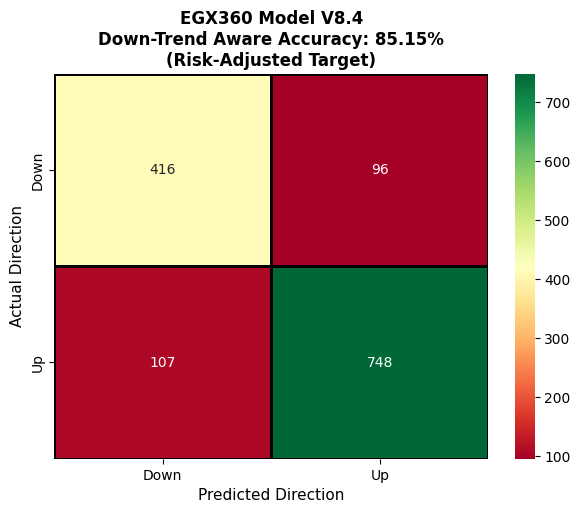

In [380]:
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred) * 100
print(f"\nDEEP QUANT ACCURACY: {acc:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down Trend (0)', 'Up Trend (1)']))

### Confusion Matrix Heatmap

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], linewidths=1, linecolor='black')
plt.title(f"EGX360 Model V8.4\nDown-Trend Aware Accuracy: {acc:.2f}%\n(Risk-Adjusted Target)", fontsize=12, fontweight='bold')
plt.xlabel('Predicted Direction', fontsize=11)
plt.ylabel('Actual Direction', fontsize=11)
plt.show()

## 8. Strategy Testing & Prediction Visualization (Signal Generation)
**Concept:** Accuracy metrics and Confusion Matrices are abstract. To truly validate a Quantitative Model, we must map its predictions back onto the chronological price chart. Here, we visualize the model's output on the unseen test data. 
* **Green Up-Triangles:** The model predicted the $EMA_{10}$ will rise (Buy/Hold Signal).
* **Red Down-Triangles:** The model predicted the $EMA_{10}$ will fall (Sell/Exit Signal).

By observing these signals against the actual price action, we can visually confirm if the model successfully avoids "Whipsaws" (false signals) and accurately rides the major trends.

### Create a DataFrame to map predictions back to dates and prices

In [381]:
# هنسحب التاريخ من الـ index ونعمله reset عشان يركب مع باقي الداتا بالمللي
test_dates = pd.Series(df.index[split:]).reset_index(drop=True)
test_close = df['close'].iloc[split:].reset_index(drop=True)
test_ema10 = df['close'].ewm(span=10).mean().iloc[split:].reset_index(drop=True)


In [382]:
results_df = pd.DataFrame({
    'timestamp': test_dates,
    'close': test_close,
    'EMA_10': test_ema10,
    'Actual_Trend': y_test,
    'Predicted_Trend': y_pred
})



### To make the chart readable, we will visualize the last 150 days of the test set

In [383]:
viz_df = results_df.tail(150)

### Create the Interactive Plotly Figure

In [384]:
fig_test = go.Figure()

### 1. Plot the actual Close Price

In [385]:
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['close'], 
                              mode='lines', name='Close Price', 
                              line=dict(color='rgba(128,128,128,0.5)', width=1.5)))

### 2. Plot the Target (EMA 10)

In [386]:
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['EMA_10'], 
                              mode='lines', name='EMA 10 (Target)', 
                              line=dict(color='blue', width=2)))

### 3. Filter predictions for visualization

In [387]:
# 3. Filter predictions for visualization
buy_signals = viz_df[viz_df['Predicted_Trend'] == 1]
sell_signals = viz_df[viz_df['Predicted_Trend'] == 0]
results_df['Predicted_Trend'] = y_pred_aggressive

### 4. Plot Model Predictions (Up = Green, Down = Red)

In [388]:
fig_test.add_trace(go.Scatter(x=buy_signals['timestamp'], y=buy_signals['EMA_10'], 
                              mode='markers', name='Model Signal: UP (1)', 
                              marker=dict(color='green', symbol='triangle-up', size=12, line=dict(width=1, color='darkgreen'))))

fig_test.add_trace(go.Scatter(x=sell_signals['timestamp'], y=sell_signals['EMA_10'], 
                              mode='markers', name='Model Signal: DOWN (0)', 
                              marker=dict(color='red', symbol='triangle-down', size=12, line=dict(width=1, color='darkred'))))

# Formatting the Chart

In [389]:
fig_test.update_layout(title='EGX360 Live Signals: Model Predictions vs Actual Market (Test Set)',
                       yaxis_title='Price (EGP)',
                       xaxis_title='Date',
                       template='plotly_white',
                       hovermode='x unified')
fig_test.show()

## 9. Strategy Backtesting & Financial Performance (ROI)
**Concept:** A high predictive accuracy is only valuable if it translates into excess financial returns (Alpha). Here, we simulate a realistic trading environment starting with 10,000 EGP. 

**Backtesting Rules to Prevent Look-Ahead Bias:**
1. The model uses today's closing data to predict tomorrow's $EMA_{10}$ direction.
2. If the prediction is UP (1), we hold the asset for tomorrow.
3. If the prediction is DOWN (0), we sell at today's close and hold cash tomorrow (0% market return).
4. We compare our strategy's cumulative returns against a standard "Buy and Hold" baseline.

## 1. Initial Setup


In [390]:
initial_capital = 10000.0

### Calculate actual daily percentage returns of the closing price
results_df['daily_return'] = results_df['close'].pct_change()
### CRITICAL: Shift the signal by 1 day to prevent look-ahead bias.
### If the model predicts '1' today, we are IN the market tomorrow.
results_df['signal'] = results_df['Predicted_Trend'].shift(1)
## 2. Strategy Return Calculation
### We only earn the daily return if our signal for that day was 1 (Hold). Otherwise, we earn 0 (Cash).

results_df['strategy_return'] = results_df['daily_return'] * results_df['signal']
### Drop the first row which will have NaNs due to shifting/pct_change

bt_df = results_df.dropna().copy()
## 3. Cumulative Returns
bt_df['cumulative_market'] = (1 + bt_df['daily_return']).cumprod()
bt_df['cumulative_strategy'] = (1 + bt_df['strategy_return']).cumprod()
## 4. Monetary Value Tracking
bt_df['portfolio_value'] = initial_capital * bt_df['cumulative_strategy']
bt_df['bh_value'] = initial_capital * bt_df['cumulative_market']


## 5. Final Metrics & Visualizing the Portfolio Growth



In [391]:

final_portfolio = bt_df['portfolio_value'].iloc[-1]
final_bh = bt_df['bh_value'].iloc[-1]

strategy_profit_pct = ((final_portfolio - initial_capital) / initial_capital) * 100
market_profit_pct = ((final_bh - initial_capital) / initial_capital) * 100

print(f" Initial Capital: {initial_capital:,.2f} EGP")
print("-" * 40)
print(f"1) Buy & Hold Strategy (Market): {final_bh:,.2f} EGP ({market_profit_pct:.2f}%)")
print(f"2) EGX360 Strategy (Model):      {final_portfolio:,.2f} EGP ({strategy_profit_pct:.2f}%)")
print("-" * 40)
outperformance = strategy_profit_pct - market_profit_pct
print(f" The EGX360 Model outperformed the market by: {outperformance:.2f}%")

fig_bt = go.Figure()

# Plot Model Strategy Portfolio
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['portfolio_value'], 
                            mode='lines', name='EGX360 Strategy', 
                            line=dict(color='green', width=2.5)))

# Plot Buy & Hold Portfolio
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['bh_value'], 
                            mode='lines', name='Buy & Hold Baseline', 
                            line=dict(color='gray', width=1.5, dash='dash')))

fig_bt.update_layout(title='EGX360 Financial Backtest: Portfolio Growth (10,000 EGP Initial)',
                     yaxis_title='Portfolio Value (EGP)',
                     xaxis_title='Date',
                     template='plotly_white',
                     hovermode='x unified')
fig_bt.show()


 Initial Capital: 10,000.00 EGP
----------------------------------------
1) Buy & Hold Strategy (Market): 42,433.67 EGP (324.34%)
2) EGX360 Strategy (Model):      61,610.89 EGP (516.11%)
----------------------------------------
 The EGX360 Model outperformed the market by: 191.77%
